# Phase 2: Modeling – Telecom Industry
## Objective:
- Customer Churn Prediction using XGBoost
- Network Traffic Anomaly Detection using K-Means
- Network Health Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [5]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
print("Unique values in target:", y.unique())
print("Missing values in target:", y.isna().sum())
print("Class distribution:\n", y.value_counts())

Unique values in target: [0 1]
Missing values in target: 0
Class distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5625, 30)
Testing shape: (1407, 30)


In [9]:
# Drop customerID ONLY if it exists
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges safely
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing values
df.dropna(inplace=True)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Define X and y AFTER cleaning
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-Test Split (Safe)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5625, 30)
Testing shape: (1407, 30)


In [10]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [11]:
# Drop ID column if exists
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

In [12]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
print(X.dtypes.unique())

[dtype('int64') dtype('float64') dtype('bool')]


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5625, 30)
Testing shape: (1407, 30)


In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7910447761194029
ROC-AUC Score: 0.8304222683529101

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



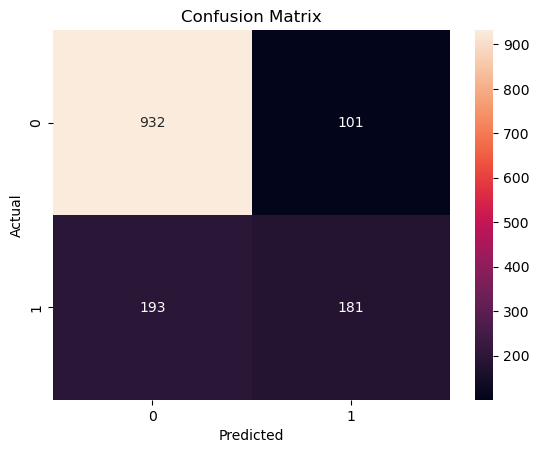

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [22]:
features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_cluster = df[features]

X_cluster.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled[:5])

[[-1.28024804 -1.16169394 -0.99419409]
 [ 0.06430269 -0.26087792 -0.17373982]
 [-1.23950408 -0.36392329 -0.95964911]
 [ 0.51248626 -0.74785042 -0.19524771]
 [-1.23950408  0.19617818 -0.94045745]]


In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts()

Cluster
1    3346
0    2215
2    1471
Name: count, dtype: int64

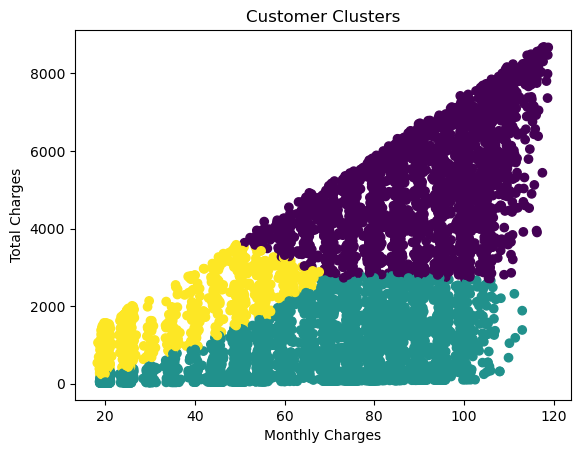

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["MonthlyCharges"], df["TotalCharges"], c=df["Cluster"])
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Customer Clusters")
plt.show()

In [26]:
import numpy as np

distances = kmeans.transform(X_scaled)
min_dist = np.min(distances, axis=1)

threshold = np.percentile(min_dist, 95)

df["Anomaly"] = min_dist > threshold

df["Anomaly"].value_counts()

Anomaly
False    6690
True      342
Name: count, dtype: int64

In [27]:
df[df["Anomaly"] == True].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Cluster,Anomaly
8,0,28,104.80,3046.05,1,False,True,False,True,False,...,False,True,False,False,True,False,True,False,0,True
14,0,25,105.50,2686.05,0,True,False,False,True,False,...,False,True,False,False,True,False,True,False,1,True
22,0,1,20.15,20.15,1,True,False,False,True,False,...,True,False,False,False,False,False,False,True,1,True
99,1,25,98.50,2514.50,1,False,True,False,True,False,...,False,True,False,False,True,False,True,False,1,True
101,0,1,19.45,19.45,0,False,True,True,True,False,...,True,False,False,False,False,False,True,False,1,True


In [28]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']